# Initial Set up

In [ ]:
from datetime import datetime

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import numpy as np

# Load Data Used In Visualization

In [ ]:
import os

# data_location denotes the location of the MIMIC-III dataset on your local machine. Change this path if your dataset is located elsewhere. Due to the size of the dataset, it is recommended to download the dataset and store it in a local directory. The dataset can be downloaded from the following link: https://physionet.org/content/mimiciii/1.4/

data_location = "../../Dataset/mimic-iii-clinical-database-1.4/"
print(os.path.exists(data_location))

In [ ]:
# Load patients data
patients = pd.read_csv(data_location + "PATIENTS.csv.gz")

patients.info()
# patients.head()


Saving PATIENTS.csv.gz to PATIENTS.csv (1).gz
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46520 entries, 0 to 46519
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ROW_ID       46520 non-null  int64 
 1   SUBJECT_ID   46520 non-null  int64 
 2   GENDER       46520 non-null  object
 3   DOB          46520 non-null  object
 4   DOD          15759 non-null  object
 5   DOD_HOSP     9974 non-null   object
 6   DOD_SSN      13378 non-null  object
 7   EXPIRE_FLAG  46520 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 2.8+ MB


In [ ]:
# Load admissions data
admissions = pd.read_csv(data_location + "ADMISSIONS.csv.gz")

admissions.info()
# admissions.head()

Saving ADMISSIONS.csv.gz to ADMISSIONS.csv (1).gz
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58976 entries, 0 to 58975
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ROW_ID                58976 non-null  int64 
 1   SUBJECT_ID            58976 non-null  int64 
 2   HADM_ID               58976 non-null  int64 
 3   ADMITTIME             58976 non-null  object
 4   DISCHTIME             58976 non-null  object
 5   DEATHTIME             5854 non-null   object
 6   ADMISSION_TYPE        58976 non-null  object
 7   ADMISSION_LOCATION    58976 non-null  object
 8   DISCHARGE_LOCATION    58976 non-null  object
 9   INSURANCE             58976 non-null  object
 10  LANGUAGE              33644 non-null  object
 11  RELIGION              58518 non-null  object
 12  MARITAL_STATUS        48848 non-null  object
 13  ETHNICITY             58976 non-null  object
 14  EDREGTIME             30877 non-null

In [ ]:
# Load ICU Stay data
icu_stays = pd.read_csv(data_location + "ICUSTAYS.csv.gz")

icu_stays.info()
# icu_stays.head()

Saving ICUSTAYS.csv.gz to ICUSTAYS.csv (1).gz
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61532 entries, 0 to 61531
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ROW_ID          61532 non-null  int64  
 1   SUBJECT_ID      61532 non-null  int64  
 2   HADM_ID         61532 non-null  int64  
 3   ICUSTAY_ID      61532 non-null  int64  
 4   DBSOURCE        61532 non-null  object 
 5   FIRST_CAREUNIT  61532 non-null  object 
 6   LAST_CAREUNIT   61532 non-null  object 
 7   FIRST_WARDID    61532 non-null  int64  
 8   LAST_WARDID     61532 non-null  int64  
 9   INTIME          61532 non-null  object 
 10  OUTTIME         61522 non-null  object 
 11  LOS             61522 non-null  float64
dtypes: float64(1), int64(6), object(5)
memory usage: 5.6+ MB


In [ ]:
# Load prescriptions data
prescriptions = pd.read_csv(data_location + "PRESCRIPTIONS.csv.gz", low_memory=False)

prescriptions.info()
# prescriptions.head()

Saving PRESCRIPTIONS.csv.gz to PRESCRIPTIONS.csv (1).gz
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4156450 entries, 0 to 4156449
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ROW_ID             int64  
 1   SUBJECT_ID         int64  
 2   HADM_ID            int64  
 3   ICUSTAY_ID         float64
 4   STARTDATE          object 
 5   ENDDATE            object 
 6   DRUG_TYPE          object 
 7   DRUG               object 
 8   DRUG_NAME_POE      object 
 9   DRUG_NAME_GENERIC  object 
 10  FORMULARY_DRUG_CD  object 
 11  GSN                object 
 12  NDC                float64
 13  PROD_STRENGTH      object 
 14  DOSE_VAL_RX        object 
 15  DOSE_UNIT_RX       object 
 16  FORM_VAL_DISP      object 
 17  FORM_UNIT_DISP     object 
 18  ROUTE              object 
dtypes: float64(2), int64(3), object(14)
memory usage: 602.5+ MB


# Calculate Patients Age

In [6]:
df = patients

In [7]:
# Calculate age function
def calculate_age(dob, dod):
    if pd.isna(dob) or pd.isna(dod):
        return pd.NA
    dob_date = datetime.strptime(dob, "%Y-%m-%d %H:%M:%S")
    dod_date = datetime.strptime(dod, "%Y-%m-%d %H:%M:%S")
    age = (dod_date - dob_date).days // 365
    return age

# Apply calculate_age function to create "age" column
df["PATIENTS_AGE"] = df.apply(lambda row: calculate_age(row["DOB"], row["DOD"]), axis=1)

# Filter out rows with age less than 120 years
patient_age_filtered_df = df[df["PATIENTS_AGE"] < 120]

In [8]:
patient_age_filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14279 entries, 1 to 46517
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ROW_ID        14279 non-null  int64 
 1   SUBJECT_ID    14279 non-null  int64 
 2   GENDER        14279 non-null  object
 3   DOB           14279 non-null  object
 4   DOD           14279 non-null  object
 5   DOD_HOSP      9081 non-null   object
 6   DOD_SSN       12117 non-null  object
 7   EXPIRE_FLAG   14279 non-null  int64 
 8   PATIENTS_AGE  14279 non-null  object
dtypes: int64(3), object(6)
memory usage: 1.1+ MB


# 1. Population Pyramid Chart (Age × Gender)

This population pyramid chart shows the age and gender distribution of patients at the time of hospital admission. Male and female admissions are mirrored across the vertical axis, allowing direct comparison across age groups.

In [12]:
# setting up age groups (bins) for analysis and visualization

age_bins = np.arange(0, 120, 5)
age_labels = [f"{i}-{i+4}" for i in age_bins[:-1]]

patient_age_filtered_df.loc[:, "AGE_GROUP"] = pd.cut(
    patient_age_filtered_df.loc[:, "PATIENTS_AGE"],
    bins=age_bins,
    labels=age_labels,
    right=False
).copy()


In [13]:
age_gender_counts = (
    patient_age_filtered_df
        .groupby(['AGE_GROUP', 'GENDER'], observed=True)
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

male_counts = -age_gender_counts['M']   # negative for left side
female_counts = age_gender_counts['F']  # positive for right side


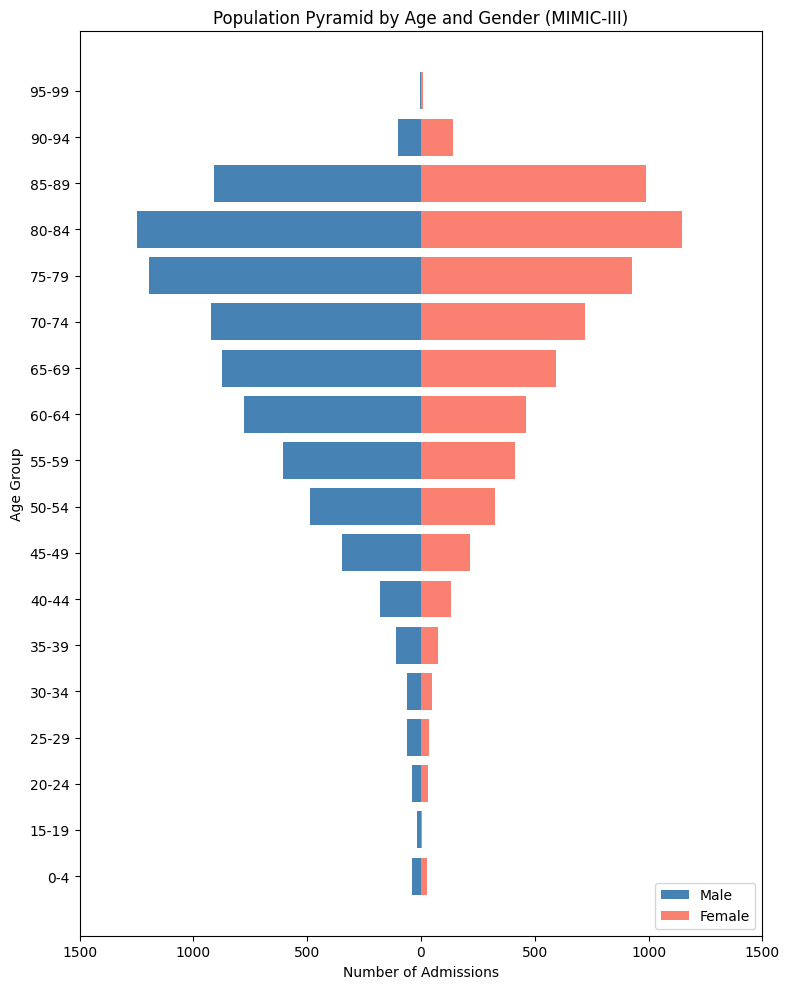

In [14]:
fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    age_gender_counts.index,
    male_counts,
    color='steelblue',
    label='Male'
)

ax.barh(
    age_gender_counts.index,
    female_counts,
    color='salmon',
    label='Female'
)


ax.set_xlabel('Number of Admissions')
ax.set_ylabel('Age Group')
ax.set_title('Population Pyramid by Age and Gender (MIMIC-III)')

ax.legend(loc='lower right')

# Make x-axis labels positive
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([abs(int(x)) for x in ax.get_xticks()])

plt.tight_layout()
plt.show()

# 2. Admission heatmap (day × hour)

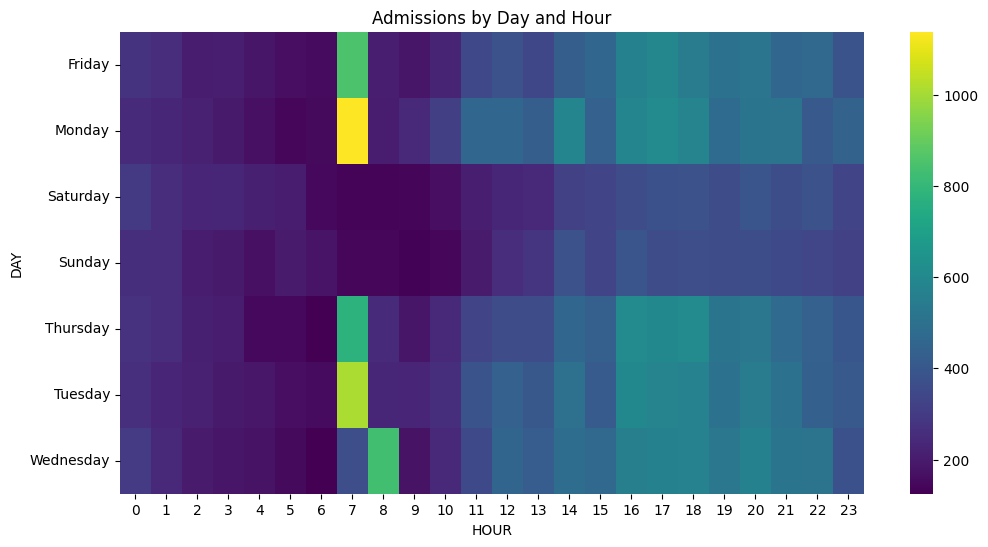

In [15]:
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'])
admissions['HOUR'] = admissions['ADMITTIME'].dt.hour
admissions['DAY'] = admissions['ADMITTIME'].dt.day_name()

pivot = admissions.pivot_table(
    index='DAY',
    columns='HOUR',
    values='HADM_ID',
    aggfunc='count'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='viridis')
plt.title('Admissions by Day and Hour')
plt.show()


# 3. Mortality vs Length of Stay Chart


In [16]:
# Convert BOTH datetime columns
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'], errors='coerce')
admissions['DISCHTIME'] = pd.to_datetime(admissions['DISCHTIME'], errors='coerce')

# Length of stay (days)
admissions['TIME_DAYS'] = (
    (admissions['DISCHTIME'] - admissions['ADMITTIME'])
    .dt.total_seconds() / 86400.0
)

# Event indicator: 1 = death, 0 = censored
admissions['EVENT'] = admissions['HOSPITAL_EXPIRE_FLAG']

# Remove invalid rows
admissions_filtered = admissions.loc[
    admissions['TIME_DAYS'].notna() &
    (admissions['TIME_DAYS'] > 0) &
    admissions['EVENT'].notna()
].copy()

admissions_filtered['MORTALITY'] = admissions_filtered['HOSPITAL_EXPIRE_FLAG'].map(
    {0: 'Survived', 1: 'Died'}
)

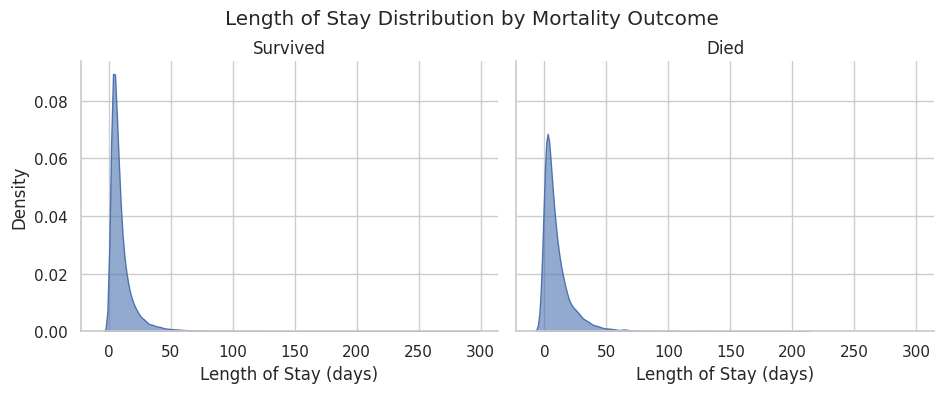

In [19]:
sns.set(style='whitegrid')

g = sns.FacetGrid(
    admissions_filtered,
    col='MORTALITY',
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.kdeplot,
    x='TIME_DAYS',
    fill=True,
    alpha=0.6
)

g.set_axis_labels('Length of Stay (days)', 'Density')
g.set_titles('{col_name}')

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Length of Stay Distribution by Mortality Outcome')

plt.show()

# 4. Survival Curve (Kaplan–Meier Style)

A Kaplan-Meier (K-M) survival curve is a step-function graph displaying the probability of an event (e.g., death, disease progression) not occurring over time. It plots time on the x-axis (0 to max) and cumulative survival probability (1.0 to 0) on the y-axis, with, 100% survival at time zero.

In [20]:
def kaplan_meier(time, event):
    df = pd.DataFrame({'time': time, 'event': event})
    df = df.sort_values('time')

    n_at_risk = len(df)
    survival_prob = 1.0

    times = [0]
    survival = [1.0]

    for t in np.unique(df['time']):
        d = df[(df['time'] == t) & (df['event'] == 1)].shape[0]
        c = df[(df['time'] == t) & (df['event'] == 0)].shape[0]

        if n_at_risk > 0:
            survival_prob *= (1 - d / n_at_risk)

        times.append(t)
        survival.append(survival_prob)

        n_at_risk -= (d + c)

    return times, survival


In [21]:
times, survival = kaplan_meier(
    admissions_filtered['TIME_DAYS'].values,
    admissions_filtered['EVENT'].values
)


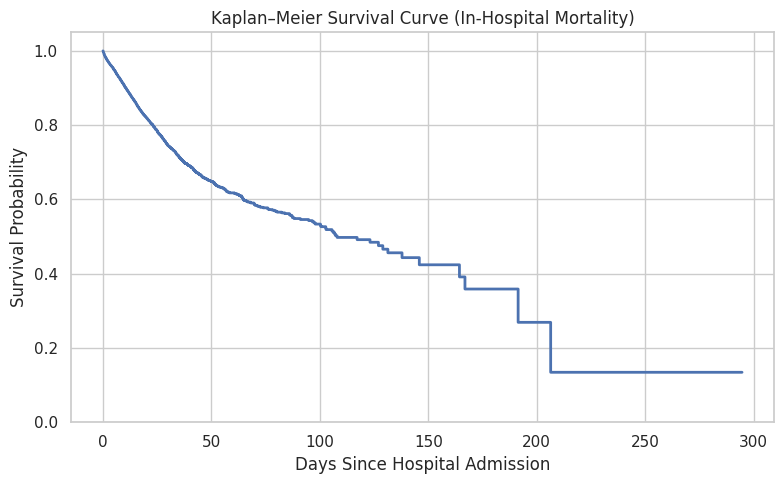

In [22]:
plt.figure(figsize=(8,5))

plt.step(
    times,
    survival,
    where='post',
    linewidth=2
)

plt.xlabel('Days Since Hospital Admission')
plt.ylabel('Survival Probability')
plt.title('Kaplan–Meier Survival Curve (In-Hospital Mortality)')

plt.ylim(0, 1.05)
plt.grid(True)

plt.tight_layout()
plt.show()


# 5. Top medication administrated in ICU

This visualization shows the most frequently administered medications during ICU stays in the MIMIC-III dataset.

In [23]:
# Merge prescriptions with ICU stays
icu_rx = prescriptions.merge(
    icu_stays[['SUBJECT_ID', 'HADM_ID']],
    on=['SUBJECT_ID', 'HADM_ID'],
    how='inner'
)

In [24]:
# Normalize medication names

icu_rx['DRUG'] = (
    icu_rx['DRUG']
    .str.upper()
    .str.strip()
)

icu_rx = icu_rx[icu_rx['DRUG'].notna()]

In [26]:
# Top medications

top_meds = (
    icu_rx['DRUG']
    .value_counts()
    .head(10)
    .reset_index()
)

top_meds.columns = ['Medication', 'Count']


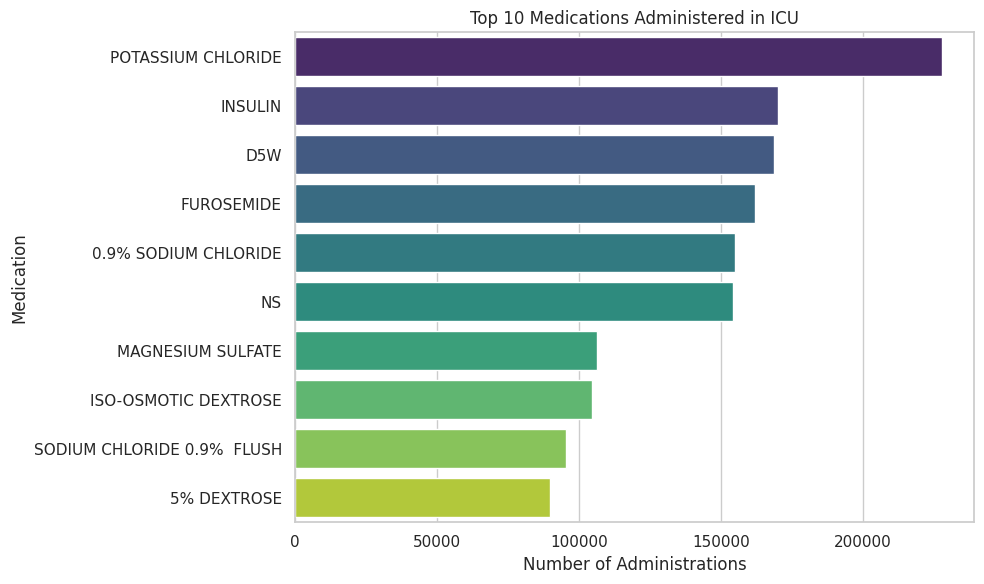

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_meds,
    y='Medication',
    x='Count',
    palette='viridis',
    hue='Medication',
    legend=False
)


plt.title('Top 10 Medications Administered in ICU')
plt.xlabel('Number of Administrations')
plt.ylabel('Medication')

plt.tight_layout()
plt.show()


# 6. ICU Length of Stay by ICU Type

In [28]:
icu_stays['LOS_DAYS'] = icu_stays['LOS']

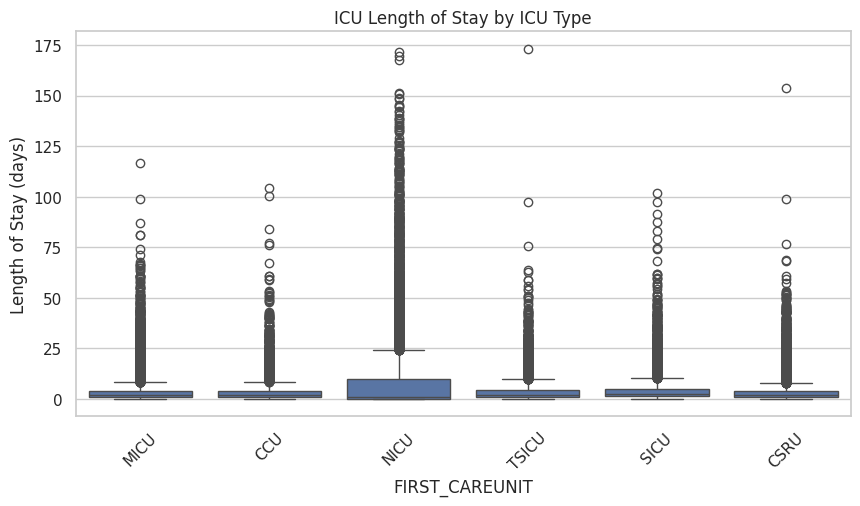

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=icu_stays,
    x='FIRST_CAREUNIT',
    y='LOS_DAYS'
)
plt.xticks(rotation=45)
plt.title('ICU Length of Stay by ICU Type')
plt.ylabel('Length of Stay (days)')
plt.show()


# 7. ICU Length of Stay vs Age

In [30]:


# Merge admissions and patients data on subject_id
merged_patients_admission_data = pd.merge(admissions, patient_age_filtered_df, on="SUBJECT_ID")

#merged_patients_admission_data.head()
# merged_patients_admission_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20598 entries, 0 to 20597
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ROW_ID_x              20598 non-null  int64         
 1   SUBJECT_ID            20598 non-null  int64         
 2   HADM_ID               20598 non-null  int64         
 3   ADMITTIME             20598 non-null  datetime64[ns]
 4   DISCHTIME             20598 non-null  datetime64[ns]
 5   DEATHTIME             5305 non-null   object        
 6   ADMISSION_TYPE        20598 non-null  object        
 7   ADMISSION_LOCATION    20598 non-null  object        
 8   DISCHARGE_LOCATION    20598 non-null  object        
 9   INSURANCE             20598 non-null  object        
 10  LANGUAGE              10919 non-null  object        
 11  RELIGION              20381 non-null  object        
 12  MARITAL_STATUS        19416 non-null  object        
 13  ETHNICITY       

In [31]:
df_los = merged_patients_admission_data.merge(icu_stays, on=['SUBJECT_ID', 'HADM_ID'])

# df_los.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22117 entries, 0 to 22116
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ROW_ID_x              22117 non-null  int64         
 1   SUBJECT_ID            22117 non-null  int64         
 2   HADM_ID               22117 non-null  int64         
 3   ADMITTIME             22117 non-null  datetime64[ns]
 4   DISCHTIME             22117 non-null  datetime64[ns]
 5   DEATHTIME             6019 non-null   object        
 6   ADMISSION_TYPE        22117 non-null  object        
 7   ADMISSION_LOCATION    22117 non-null  object        
 8   DISCHARGE_LOCATION    22117 non-null  object        
 9   INSURANCE             22117 non-null  object        
 10  LANGUAGE              11818 non-null  object        
 11  RELIGION              21881 non-null  object        
 12  MARITAL_STATUS        20865 non-null  object        
 13  ETHNICITY       

In [32]:

fig = px.scatter(
    df_los,
    x='PATIENTS_AGE',
    y='LOS',
    color='GENDER',
    title='ICU Length of Stay vs Age'
)
fig.show()
